In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter


df = pd.read_csv('cleaned_student_data.csv')

In [3]:
df2 = df.copy()

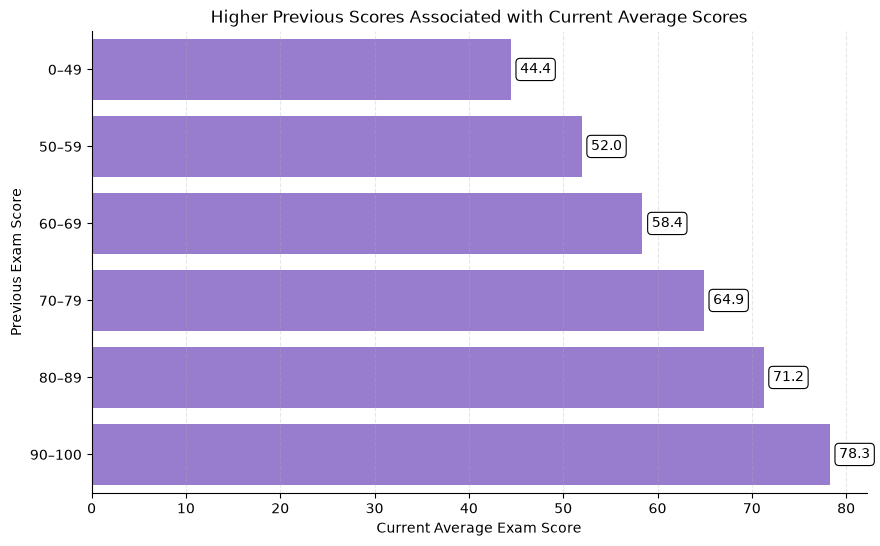

In [7]:
score_groups = pd.cut(
    df2["previous_exam_score"],
    bins=[0, 49, 59, 69, 79, 89, 100],
    labels=["0–49", "50–59", "60–69", "70–79", "80–89", "90–100"]
)

plot_df = (
    df2.assign(score_group=score_groups)
       .groupby("score_group", observed=True)["exam_score"]
       .mean()
       .reset_index()
)


#plotting
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df,
    x="exam_score",
    y="score_group",
    color="mediumpurple"
)

for bar in ax.patches:
    value = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax.text(
        value + 1,
        y,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        )
    )

plt.xlabel("Current Average Exam Score")
plt.ylabel("Previous Exam Score")
plt.title("Higher Previous Scores Associated with Current Average Scores")
sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()

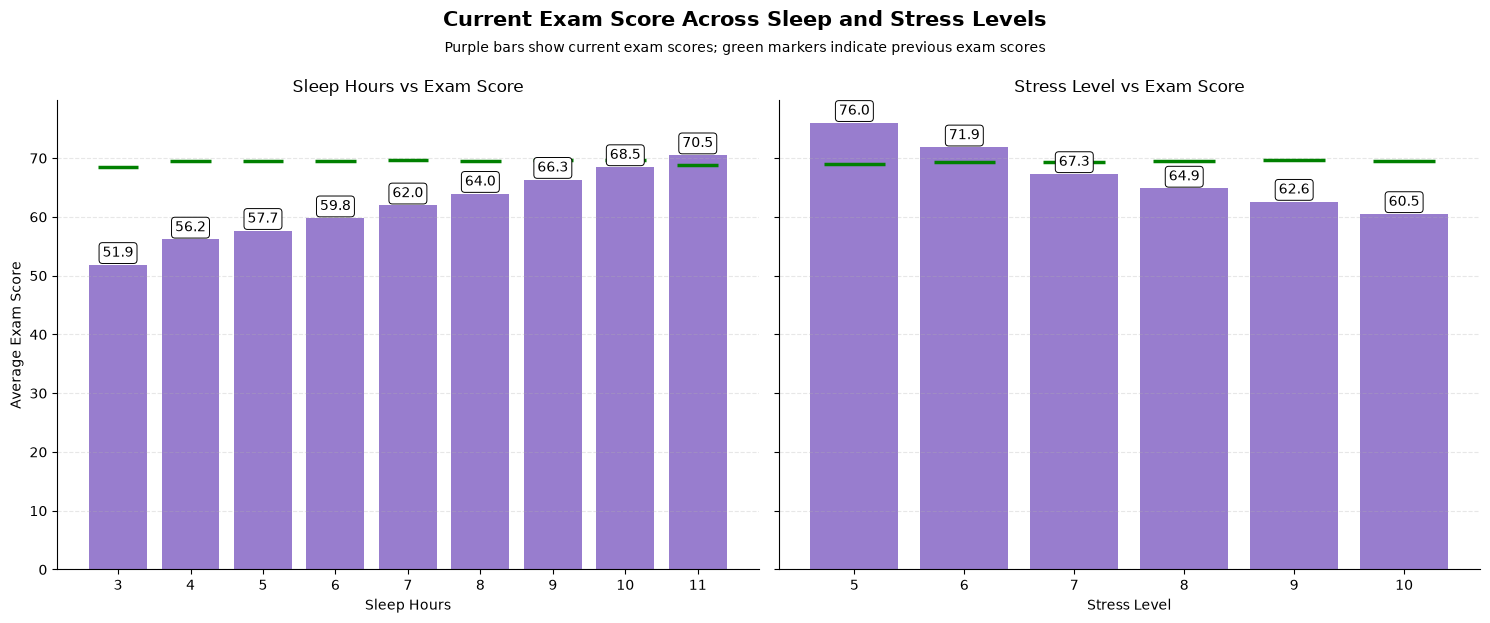

In [37]:
df2["sleep_group"] = np.floor(df2["sleep_hours"] + 0.5).astype(int)

sleep_score = (
    df2.groupby("sleep_group")[["exam_score", "previous_exam_score"]]
       .mean()
       .reset_index()
)

stress_score = (
    df2.groupby("stress_level")[["exam_score", "previous_exam_score"]]
       .mean()
       .reset_index()
)


fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

fig.suptitle(
    "Current Exam Score Across Sleep and Stress Levels",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

fig.text(
    0.5, 0.96,
    "Purple bars show current exam scores; green markers indicate previous exam scores",
    ha="center",
    fontsize=10
)

for ax, data, x_col, title, xlabel in [
    (axes[0], sleep_score, "sleep_group",
     "Sleep Hours vs Exam Score", "Sleep Hours"),

    (axes[1], stress_score, "stress_level",
     "Stress Level vs Exam Score", "Stress Level")
]:

    sns.barplot(
        data=data,
        x=x_col,
        y="exam_score",
        color="mediumpurple",
        ax=ax
    )

    for bar in ax.patches:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.8,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="black",
                linewidth=0.7
            )
        )

    # Previous score
    for i, previous in enumerate(data["previous_exam_score"]):

        ax.hlines(
        y=previous,
        xmin=i - 0.28,
        xmax=i + 0.28,
        linewidth=2.5,
        color="green"
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", linestyle="--", alpha=0.3)


axes[0].set_ylabel("Average Exam Score")
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

In [24]:
bins = [0, 49, 59, 69, 79, 89, 100]
labels = ["0–49", "50–59", "60–69", "70–79", "80–89", "90–100"]

df2["previous_group"] = pd.cut(
    df2["previous_exam_score"],
    bins=bins,
    labels=labels
)

df2["current_group"] = pd.cut(
    df2["exam_score"],
    bins=bins,
    labels=labels
)

df2["performance_change"] = np.select(
    [
        df2["current_group"].cat.codes > df2["previous_group"].cat.codes,
        df2["current_group"].cat.codes < df2["previous_group"].cat.codes
    ],
    ["Improved", "Declined"],
    default="Same"
)

# Change table
change_table = (
    df2.groupby(["previous_group", "performance_change"], observed=True)
       .size()
       .unstack(fill_value=0)
       .reindex(columns=["Improved", "Declined", "Same"], fill_value=0)
)

# Declined percentage
change_table["Declined_pct"] = (
    change_table["Declined"]
    / change_table[["Improved", "Declined", "Same"]].sum(axis=1)
    * 100
).round(1)

change_table

performance_change,Improved,Declined,Same,Declined_pct
previous_group,,,,
0–49,1343,2,2179,0.1
50–59,4413,6040,3934,42.0
60–69,6750,15806,7672,52.3
70–79,4820,19488,7301,61.7
80–89,1632,11184,2933,71.0
90–100,0,3481,1022,77.3


In [25]:
metrics = [
    "sleep_hours",
    "daily_screen_time",
    "self_study_hours",
    "stress_level",
    "practice_tests_completed"
]

comparison_table = (
    df2[df2["performance_change"].isin(["Improved", "Declined"])]
    .groupby("performance_change")[metrics]
    .mean()
    .T
    .round(2)
)

comparison_table

performance_change,Declined,Improved
sleep_hours,6.84,7.32
daily_screen_time,5.00,5.00
self_study_hours,1.77,2.88
stress_level,9.51,9.08
practice_tests_completed,4.90,6.88
